1. Load the CSV file (`messy_data.csv`) into a pandas DataFrame. 

In [396]:
import pandas as pd
import numpy as np
df = pd.read_csv('../data/messy_data.csv')
df.head(11)

,id,age,height,weight,income,purchases,gender
0,1,25.0,175.0,68,35000.0,"23,45,12",male
1,2,NaN,182.0,80,42000.0,"34,,19",female
2,3,150.0,165.0,180,28000.0,NaN,unknown
3,4,34.0,168.0,70,NaN,",55,67",male
4,5,29.0,190.0,165,31000.0,"12,19,23",female
5,6,42.0,NaN,82,37000.0,"40,41,42",male
6,7,NaN,-99.0,190,NaN,"23,,",female
7,8,38.0,172.0,75,39000.0,"22,20",unknown
8,9,44.0,180.0,160,41000.0,NaN,male
9,10,33.0,160.0,130,0.0,"14,13,12",other


2. Explore the data
- 2 missing value in age
- 1 missing value in height
- 2 missing value in income
- 6 missing value in purchases
- Unrealistic age values (age = 150)
- Unrealistic height values (height = -99)
- Type issue in height => height is not numeric


In [397]:
df['height'] = pd.to_numeric(df['height'], errors='coerce')
df['height'].dtype

dtype('float64')

3. Clean the data step-by-step: 

Step 1: - Identify and process outliers (you define the thresholds) 

In [398]:
max_age = 100
df['age'] = df['age'].apply(lambda x : min(x, max_age))
df.head(11)

,id,age,height,weight,income,purchases,gender
0,1,25.0,175.0,68,35000.0,"23,45,12",male
1,2,NaN,182.0,80,42000.0,"34,,19",female
2,3,100.0,165.0,180,28000.0,NaN,unknown
3,4,34.0,168.0,70,NaN,",55,67",male
4,5,29.0,190.0,165,31000.0,"12,19,23",female
5,6,42.0,NaN,82,37000.0,"40,41,42",male
6,7,NaN,-99.0,190,NaN,"23,,",female
7,8,38.0,172.0,75,39000.0,"22,20",unknown
8,9,44.0,180.0,160,41000.0,NaN,male
9,10,33.0,160.0,130,0.0,"14,13,12",other


 Ensure all height values are valid (e.g., no negatives)

In [399]:
df.loc[df['height'] < 0, 'height'] = np.nan
df.head(11)

,id,age,height,weight,income,purchases,gender
0,1,25.0,175.0,68,35000.0,"23,45,12",male
1,2,NaN,182.0,80,42000.0,"34,,19",female
2,3,100.0,165.0,180,28000.0,NaN,unknown
3,4,34.0,168.0,70,NaN,",55,67",male
4,5,29.0,190.0,165,31000.0,"12,19,23",female
5,6,42.0,NaN,82,37000.0,"40,41,42",male
6,7,NaN,NaN,190,NaN,"23,,",female
7,8,38.0,172.0,75,39000.0,"22,20",unknown
8,9,44.0,180.0,160,41000.0,NaN,male
9,10,33.0,160.0,130,0.0,"14,13,12",other


Step 2:  Handle missing values 

In [400]:
average_age = df['age'].mean()
average_height = df['height'].mean()
average_income = df['income'].mean()

In [401]:
df['age'] = df['age'].fillna(round(average_age))
df['height'] = df['height'].fillna(round(average_height))
df['income'] = df['income'].fillna(round(average_income))

In [402]:
df.head(11)

,id,age,height,weight,income,purchases,gender
0,1,25.0,175.0,68,35000.0,"23,45,12",male
1,2,43.0,182.0,80,42000.0,"34,,19",female
2,3,100.0,165.0,180,28000.0,NaN,unknown
3,4,34.0,168.0,70,31625.0,",55,67",male
4,5,29.0,190.0,165,31000.0,"12,19,23",female
5,6,42.0,174.0,82,37000.0,"40,41,42",male
6,7,43.0,174.0,190,31625.0,"23,,",female
7,8,38.0,172.0,75,39000.0,"22,20",unknown
8,9,44.0,180.0,160,41000.0,NaN,male
9,10,33.0,160.0,130,0.0,"14,13,12",other


Step 3:  Normalize relevant numerical columns (e.g., height, weight, income) 

In [403]:
max_height = df['height'].max()
max_weight = df['weight'].max()
max_income = df['income'].max()

max_height = max_height if max_height !=0 else 1
max_weight = max_weight if max_weight !=0 else 1
max_income = max_income if max_income !=0 else 1

df['height'] = df['height'] / max_height
df['weight'] = df['weight'] / max_weight
df['income'] = df['income'] / max_income

df[['id', 'height', 'weight', 'income']].head(11)

,id,height,weight,income
0,1,0.921053,0.357895,0.833333
1,2,0.957895,0.421053,1.000000
2,3,0.868421,0.947368,0.666667
3,4,0.884211,0.368421,0.752976
4,5,1.000000,0.868421,0.738095
5,6,0.915789,0.431579,0.880952
6,7,0.915789,1.000000,0.752976
7,8,0.905263,0.394737,0.928571
8,9,0.947368,0.842105,0.976190
9,10,0.842105,0.684211,0.000000


Step 4: Convert categorical values to numerical format using one-hot encoding 

In [404]:
df['gender'] = df['gender'].astype(str)

In [405]:
df['gender'] = df['gender'].apply(
    lambda g: [1, 0] if g == 'male'
    else [0, 1] if g == 'female'
    else [0, 0] if g == 'other'
    else [1, 1]
)

df.head(10)

,id,age,height,weight,income,purchases,gender
0,1,25.0,0.921053,0.357895,0.833333,"23,45,12","[1, 0]"
1,2,43.0,0.957895,0.421053,1.000000,"34,,19","[0, 1]"
2,3,100.0,0.868421,0.947368,0.666667,NaN,"[1, 1]"
3,4,34.0,0.884211,0.368421,0.752976,",55,67","[1, 0]"
4,5,29.0,1.000000,0.868421,0.738095,"12,19,23","[0, 1]"
5,6,42.0,0.915789,0.431579,0.880952,"40,41,42","[1, 0]"
6,7,43.0,0.915789,1.000000,0.752976,"23,,","[0, 1]"
7,8,38.0,0.905263,0.394737,0.928571,"22,20","[1, 1]"
8,9,44.0,0.947368,0.842105,0.976190,NaN,"[1, 0]"
9,10,33.0,0.842105,0.684211,0.000000,"14,13,12","[0, 0]"


4. Convert the `purchases` column: 

In [ ]:
def clean_purchases(purchases):
  if pd.isna(purchases):
    return []
  return [0 if p == '' else int(p) for p in purchases.split(',')]
df['purchases'] = df['purchases'].apply(clean_purchases)
df.head(11)

,id,age,height,weight,income,purchases,gender
0,1,25.0,0.921053,0.357895,0.833333,"[23, 45, 12]","[1, 0]"
1,2,43.0,0.957895,0.421053,1.000000,"[34, 0, 19]","[0, 1]"
2,3,100.0,0.868421,0.947368,0.666667,[],"[1, 1]"
3,4,34.0,0.884211,0.368421,0.752976,"[0, 55, 67]","[1, 0]"
4,5,29.0,1.000000,0.868421,0.738095,"[12, 19, 23]","[0, 1]"
5,6,42.0,0.915789,0.431579,0.880952,"[40, 41, 42]","[1, 0]"
6,7,43.0,0.915789,1.000000,0.752976,"[23, 0, 0]","[0, 1]"
7,8,38.0,0.905263,0.394737,0.928571,"[22, 20]","[1, 1]"
8,9,44.0,0.947368,0.842105,0.976190,[],"[1, 0]"
9,10,33.0,0.842105,0.684211,0.000000,"[14, 13, 12]","[0, 0]"


5. Save your cleaned DataFrame as a new CSV file (`cleaned_data.csv`).

In [407]:
df_new = '../data/cleaned_data.csv'
df.to_csv(df_new)


� Optional Challenge 

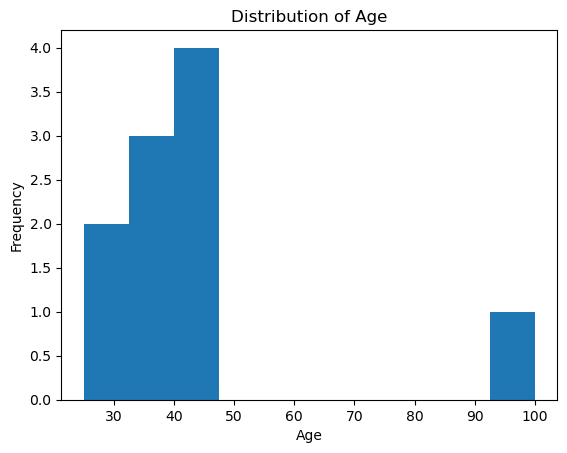

In [417]:
import matplotlib.pyplot as plt
plt.hist(df['age'], bins=10)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()
